In [2]:
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
data = pd.read_csv("/content/predict_energy_consumption.xls")

In [4]:
data.shape

(1000, 5)

In [6]:
print(data.head())

   temperature   humidity  wind_speed  solar_irradiance  energy_consumption
0    24.363503  31.107976    5.234114        705.432695          307.398145
1    38.767858  52.514057    4.939576        817.013257          412.444548
2    33.299849  72.376750   18.125092        325.421109          392.072418
3    29.966462  63.933493    4.990924        662.386690          119.254957
4    18.900466  68.393669    5.438995        614.571385          117.162261


In [10]:
print(data.tail())

     temperature   humidity  wind_speed  solar_irradiance  energy_consumption
995    17.289552  59.417309   17.305915        497.896331          453.828793
996    37.932839  77.396877    3.145464        400.961061          103.721455
997    18.420466  24.137481    6.195757        455.115084          197.529277
998    38.755934  23.423283    5.800911        576.946528          417.085421
999    26.150144  36.931224   17.428281        245.230623          318.790570


In [13]:
data.isnull().sum() .sum()

np.int64(0)

In [16]:
data.columns

Index(['temperature', 'humidity', 'wind_speed', 'solar_irradiance',
       'energy_consumption'],
      dtype='object')

In [17]:
X = data[['temperature', 'humidity', 'wind_speed', 'solar_irradiance']]
y = data[["energy_consumption"]]



In [18]:
X_train,X_test,y_train,y_test = train_test_split(X , y, test_size=0.2,random_state=42)

In [19]:
scaler = StandardScaler() # each and every feature come on same range
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#

In [21]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(optimizer='adam', loss="mse",metrics=['mae'])

In [24]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2,verbose=1)
#

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 90412.1641 - mae: 271.7945 - val_loss: 83738.4609 - val_mae: 259.1057
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 90000.5625 - mae: 271.0401 - val_loss: 83272.3594 - val_mae: 258.2097
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 89409.6875 - mae: 269.9411 - val_loss: 82565.6719 - val_mae: 256.8455
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 88510.2656 - mae: 268.2592 - val_loss: 81501.4766 - val_mae: 254.7750
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 87170.9609 - mae: 265.7488 - val_loss: 79937.1250 - val_mae: 251.6985
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 85219.2656 - mae: 262.0695 - val_loss: 77714.1875 - val_mae: 247.2546
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 82509.2031 - mae: 256.8243 - val_loss: 74691.7578 - val_mae: 241.0701
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 78862.1875 - mae: 249.6993 - val_loss: 7

In [26]:
test_loss,test_mae = model.evaluate(X_test,y_test,verbose=1)
print(f" test Mean Absolute Error{test_mae:.2f}")
#

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 17969.4824 - mae: 115.2052 
 test Mean Absolute Error115.21


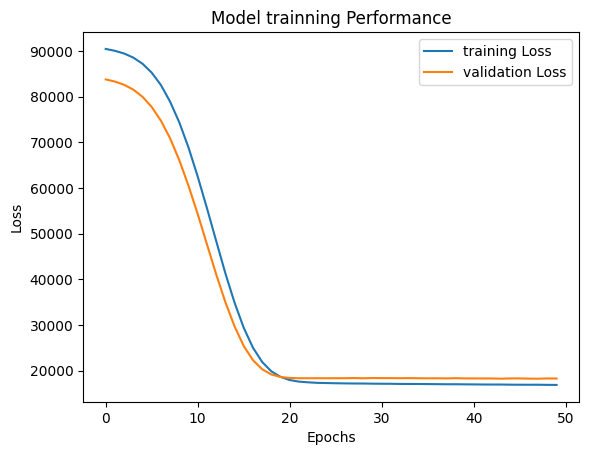

In [32]:
plt.plot(history.history['loss'],label='training Loss')
plt.plot(history.history['val_loss'],label='validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model trainning Performance")
plt.legend()
plt.show()
#

In [34]:
prediction = model.predict(X_test)
print(prediction)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
[[283.09415]
 [254.06013]
 [252.98056]
 [212.37672]
 [354.66696]
 [321.8201 ]
 [322.35715]
 [290.21497]
 [282.00092]
 [279.0983 ]
 [237.50725]
 [269.46893]
 [275.72046]
 [235.9481 ]
 [310.7058 ]
 [309.9895 ]
 [262.1292 ]
 [308.24954]
 [299.30292]
 [244.18663]
 [270.34253]
 [286.00775]
 [275.57785]
 [278.4772 ]
 [248.57312]
 [247.09544]
 [261.64468]
 [315.2885 ]
 [313.27957]
 [270.14383]
 [232.41743]
 [302.99942]
 [286.74   ]
 [267.7071 ]
 [323.08606]
 [286.13907]
 [218.84026]
 [260.72147]
 [279.69604]
 [232.34932]
 [248.32645]
 [252.90936]
 [245.07202]
 [255.26659]
 [259.74893]
 [258.05582]
 [258.2362 ]
 [253.129  ]
 [285.88434]
 [300.95102]
 [222.94919]
 [267.10083]
 [256.2438 ]
 [211.55946]
 [308.38052]
 [300.36884]
 [241.73912]
 [280.9898 ]
 [264.22787]
 [277.62186]
 [264.22925]
 [284.57678]
 [281.77356]
 [324.95828]
 [309.56967]
 [265.56   ]
 [305.1898 ]
 [248.23099]
 [243.98123]
 [231.66493]
 [304.65598]
 [255.8326 ]
 [285.5365 ]
 [254.08348]


<function matplotlib.pyplot.show(close=None, block=None)>

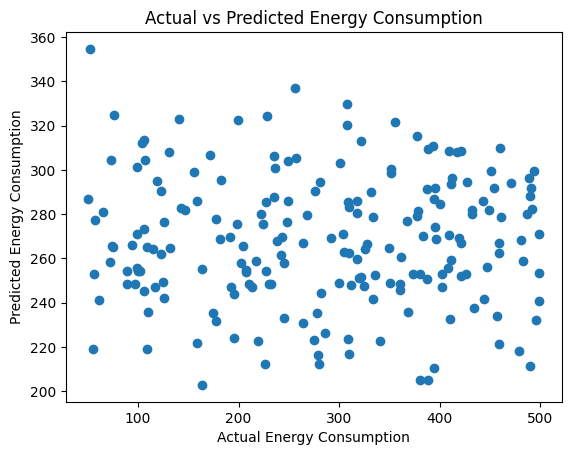

In [37]:
plt.scatter(y_test,prediction)
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")
plt.show

In [36]:
plt.show()